In [215]:
import pandas as pd

# Load data from a local CSV file
df = pd.read_csv("Concrete_Data.csv")

In [216]:
df

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [18]:
df_norm = (df - df.min()) / (df.max() - df.min())
df = df.add_suffix('_raw').join(df_norm.add_suffix('_norm'))


In [217]:
df_std = (df - df.mean()) / df.std()
df = df.add_suffix('_raw').join(df_std.add_suffix('_std'))



In [218]:
test_df = df.iloc[500+1:630+1]                     # rows 500 to 629 since i start at 0
train_df = pd.concat([df.iloc[:500+1], df.iloc[630+1:]], ignore_index=True)

In [219]:
train_df.iloc[1]

Cement (component 1)(kg in a m^3 mixture)_raw                 540.000000
Blast Furnace Slag (component 2)(kg in a m^3 mixture)_raw       0.000000
Fly Ash (component 3)(kg in a m^3 mixture)_raw                  0.000000
Water  (component 4)(kg in a m^3 mixture)_raw                 162.000000
Superplasticizer (component 5)(kg in a m^3 mixture)_raw         2.500000
Coarse Aggregate  (component 6)(kg in a m^3 mixture)_raw     1055.000000
Fine Aggregate (component 7)(kg in a m^3 mixture)_raw         676.000000
Age (day)_raw                                                  28.000000
Concrete compressive strength(MPa, megapascals) _raw           61.890000
Cement (component 1)(kg in a m^3 mixture)_std                   2.476712
Blast Furnace Slag (component 2)(kg in a m^3 mixture)_std      -0.856472
Fly Ash (component 3)(kg in a m^3 mixture)_std                 -0.846733
Water  (component 4)(kg in a m^3 mixture)_std                  -0.916319
Superplasticizer (component 5)(kg in a m^3 mixture)

In [63]:
train_df

,Cement (component 1)(kg in a m^3 mixture)_raw,Blast Furnace Slag (component 2)(kg in a m^3 mixture)_raw,Fly Ash (component 3)(kg in a m^3 mixture)_raw,Water (component 4)(kg in a m^3 mixture)_raw,Superplasticizer (component 5)(kg in a m^3 mixture)_raw,Coarse Aggregate (component 6)(kg in a m^3 mixture)_raw,Fine Aggregate (component 7)(kg in a m^3 mixture)_raw,Age (day)_raw,"Concrete compressive strength(MPa, megapascals) _raw",Cement (component 1)(kg in a m^3 mixture)_std,Blast Furnace Slag (component 2)(kg in a m^3 mixture)_std,Fly Ash (component 3)(kg in a m^3 mixture)_std,Water (component 4)(kg in a m^3 mixture)_std,Superplasticizer (component 5)(kg in a m^3 mixture)_std,Coarse Aggregate (component 6)(kg in a m^3 mixture)_std,Fine Aggregate (component 7)(kg in a m^3 mixture)_std,Age (day)_std,"Concrete compressive strength(MPa, megapascals) _std"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,2.476712,-0.856472,-0.846733,-0.916319,-0.620147,0.862735,-1.217079,-0.279597,2.644123
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,2.476712,-0.856472,-0.846733,-0.916319,-0.620147,1.055651,-1.217079,-0.279597,1.560663
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,0.491187,0.795140,-0.846733,2.174405,-1.038638,-0.526262,-2.239829,3.551340,0.266498
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,0.491187,0.795140,-0.846733,2.174405,-1.038638,-0.526262,-2.239829,5.055221,0.313188
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,-0.790075,0.678079,-0.846733,0.488555,-1.038638,0.070492,0.647569,4.976069,0.507732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28,-0.045623,0.487998,0.564271,-0.092126,0.451190,-1.322363,-0.065861,-0.279597,0.506535
896,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18,0.392628,-0.856472,0.959602,0.675872,0.702285,-1.993711,0.496651,-0.279597,-0.277627
897,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70,-1.269472,0.759210,0.850222,0.521336,-0.017520,-1.035561,0.080068,-0.279597,-0.725377
898,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77,-1.168042,1.307430,-0.846733,-0.279443,0.852942,0.214537,0.191074,-0.279597,-0.182450


In [220]:
train_df.columns

Index(['Cement (component 1)(kg in a m^3 mixture)_raw',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)_raw',
       'Fly Ash (component 3)(kg in a m^3 mixture)_raw',
       'Water  (component 4)(kg in a m^3 mixture)_raw',
       'Superplasticizer (component 5)(kg in a m^3 mixture)_raw',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)_raw',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)_raw',
       'Age (day)_raw', 'Concrete compressive strength(MPa, megapascals) _raw',
       'Cement (component 1)(kg in a m^3 mixture)_std',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)_std',
       'Fly Ash (component 3)(kg in a m^3 mixture)_std',
       'Water  (component 4)(kg in a m^3 mixture)_std',
       'Superplasticizer (component 5)(kg in a m^3 mixture)_std',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)_std',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)_std',
       'Age (day)_std',
       'Concrete compressive

In [246]:

X_cols = [
    'Cement (component 1)(kg in a m^3 mixture)_std',
    'Blast Furnace Slag (component 2)(kg in a m^3 mixture)_std',
    'Fly Ash (component 3)(kg in a m^3 mixture)_std',
    'Water  (component 4)(kg in a m^3 mixture)_std',
    'Superplasticizer (component 5)(kg in a m^3 mixture)_std',
    'Coarse Aggregate  (component 6)(kg in a m^3 mixture)_std',
    'Fine Aggregate (component 7)(kg in a m^3 mixture)_std',
    'Age (day)_std'
]


X = train_df[X_cols]
y=train_df['Concrete compressive strength(MPa, megapascals) _raw'].values

alpha = 0.00000001 
m = np.ones(X.shape[1])  
b = 1.0
max_iter = 1000




m_new, b_new = gradient_descent2(alpha, X, y, m, b, max_iter)

IndexError: index 900 is out of bounds for axis 0 with size 900

In [272]:
X_cols = [
    'Cement (component 1)(kg in a m^3 mixture)_std',
    'Blast Furnace Slag (component 2)(kg in a m^3 mixture)_std',
    'Fly Ash (component 3)(kg in a m^3 mixture)_std',
    'Water  (component 4)(kg in a m^3 mixture)_std',
    'Superplasticizer (component 5)(kg in a m^3 mixture)_std',
    'Coarse Aggregate  (component 6)(kg in a m^3 mixture)_std',
    'Fine Aggregate (component 7)(kg in a m^3 mixture)_std',
    'Age (day)_std'
]

# Make sure you use the same df for both X and y:
X_train = train_df[X_cols].to_numpy()
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].to_numpy()

alpha = 1e-3  # larger since data is standardized
m = np.ones(X.shape[1])
b = 1.0
max_iter = 40000

m_new, b_new = gradient_descent2(alpha, X_train, y_train, m, b, max_iter)

print("Updated m:", m_new)

X_test = test_df[X_cols].to_numpy()
y_test = test_df['Concrete compressive strength(MPa, megapascals) _raw'].to_numpy()

y_pred_train = np.dot(X_train, m_new) + b_new
y_pred_test  = np.dot(X_test, m_new) + b_new

# MSE
mse_train = np.mean((y_train - y_pred_train)**2)
mse_test  = np.mean((y_test - y_pred_test)**2)

# R²
ss_total_train = np.sum((y_train - np.mean(y_train))**2)
ss_res_train   = np.sum((y_train - y_pred_train)**2)
r2_train = 1 - (ss_res_train / ss_total_train)

ss_total_test = np.sum((y_test - np.mean(y_test))**2)
ss_res_test   = np.sum((y_test - y_pred_test)**2)
r2_test = 1 - (ss_res_test / ss_total_test)

print("Train MSE:", mse_train)
print("Test  MSE:", mse_test)
print("Train Rsq:", r2_train)
print("Test  Rsq:", r2_test)

ValueError: shapes (8,) and (1,) not aligned: 8 (dim 0) != 1 (dim 0)

In [259]:
b_new

np.float64(36.54246998974393)

In [256]:
# y_pred = np.dot(X, m_new) + b_new

# # === Evaluation ===
# mse = np.mean((y - y_pred) ** 2)
# ss_total = np.sum((y - np.mean(y)) ** 2)
# ss_res = np.sum((y - y_pred) ** 2)
# r2 = 1 - (ss_res / ss_total)

# print("Final Results:")
# print("m =", m_new)
# print("b =", b_new)
# print(f"MSE = {mse:.4f}")
# print(f"R²  = {r2:.4f}")

Final Results:
m = [12.14494749  8.59349152  5.30624206 -3.52844462  1.70216855  1.11238522
  1.25417744  7.20456053]
b = 35.81796116504678
MSE = 107.2185
R²  = 0.6154


In [260]:
X_test = test_df[X_cols].to_numpy()
y_test = test_df['Concrete compressive strength(MPa, megapascals) _raw'].to_numpy()

y_pred_train = np.dot(X_train, m_new) + b_new
y_pred_test  = np.dot(X_test, m_new) + b_new

# MSE
mse_train = np.mean((y_train - y_pred_train)**2)
mse_test  = np.mean((y_test - y_pred_test)**2)

# R²
ss_total_train = np.sum((y_train - np.mean(y_train))**2)
ss_res_train   = np.sum((y_train - y_pred_train)**2)
r2_train = 1 - (ss_res_train / ss_total_train)

ss_total_test = np.sum((y_test - np.mean(y_test))**2)
ss_res_test   = np.sum((y_test - y_pred_test)**2)
r2_test = 1 - (ss_res_test / ss_total_test)

print("Train MSE:", mse_train)
print("Test  MSE:", mse_test)
print("Train Rsq:", r2_train)
print("Test  Rsq:", r2_test)

Train MSE: 104.20380934526243
Test  MSE: 139.62464357108826
Train R²: 0.6239220183279023
Test  R²: 0.35875284231886195


In [265]:
X_cols = [
    'Cement (component 1)(kg in a m^3 mixture)_raw',
    'Blast Furnace Slag (component 2)(kg in a m^3 mixture)_raw',
    'Fly Ash (component 3)(kg in a m^3 mixture)_raw',
    'Water  (component 4)(kg in a m^3 mixture)_raw',
    'Superplasticizer (component 5)(kg in a m^3 mixture)_raw',
    'Coarse Aggregate  (component 6)(kg in a m^3 mixture)_raw',
    'Fine Aggregate (component 7)(kg in a m^3 mixture)_raw',
    'Age (day)_raw'
]

# Make sure you use the same df for both X and y:
X_train = train_df[X_cols].to_numpy()
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].to_numpy()

alpha = 1e-7  # larger since data is standardized
m = np.ones(X.shape[1])
b = 1.0
max_iter = 40000

m_new, b_new = gradient_descent2(alpha, X_train, y_train, m, b, max_iter)

print("Updated m:", m_new)

X_test = test_df[X_cols].to_numpy()
y_test = test_df['Concrete compressive strength(MPa, megapascals) _raw'].to_numpy()

y_pred_train = np.dot(X_train, m_new) + b_new
y_pred_test  = np.dot(X_test, m_new) + b_new

# MSE
mse_train = np.mean((y_train - y_pred_train)**2)
mse_test  = np.mean((y_test - y_pred_test)**2)

# R²
ss_total_train = np.sum((y_train - np.mean(y_train))**2)
ss_res_train   = np.sum((y_train - y_pred_train)**2)
r2_train = 1 - (ss_res_train / ss_total_train)

ss_total_test = np.sum((y_test - np.mean(y_test))**2)
ss_res_test   = np.sum((y_test - y_pred_test)**2)
r2_test = 1 - (ss_res_test / ss_total_test)

print("Train MSE:", mse_train)
print("Test  MSE:", mse_test)
print("Train Rsq:", r2_train)
print("Test  Rsq:", r2_test)

Updated m: [ 0.09088864  0.07562275  0.03431826 -0.11608052  0.88341692  0.0148928
 -0.0025486   0.11660225]
Train MSE: 113.60687134459327
Test  MSE: 110.4090740682624
Train R²: 0.5899857870090545
Test  R²: 0.4929297356277028


In [266]:
b_new

np.float64(0.9966147638432589)

In [226]:
X.shape[1]

8

In [64]:
X_train = train_df['Cement (component 1)(kg in a m^3 mixture)_std'].values
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].values
X_test  = test_df['Cement (component 1)(kg in a m^3 mixture)_std'].values
y_test  = test_df['Concrete compressive strength(MPa, megapascals) _raw'].values
alpha = 0.0001       # learning rate
max_iter = 10000

In [75]:
X_train = train_df['Blast Furnace Slag (component 2)(kg in a m^3 mixture)_std'].values
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].values
X_test  = test_df['Blast Furnace Slag (component 2)(kg in a m^3 mixture)_std'].values
y_test  = test_df['Concrete compressive strength(MPa, megapascals) _raw'].values
alpha = 0.0001       # learning rate
max_iter = 10000


In [81]:
X_train = train_df['Fly Ash (component 3)(kg in a m^3 mixture)_std'].values
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].values
X_test  = test_df['Fly Ash (component 3)(kg in a m^3 mixture)_std'].values
y_test  = test_df['Concrete compressive strength(MPa, megapascals) _raw'].values
alpha = 0.0001       # learning rate
max_iter = 10000


In [83]:
X_train = train_df['Water  (component 4)(kg in a m^3 mixture)_std'].values
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].values
X_test  = test_df['Water  (component 4)(kg in a m^3 mixture)_std'].values
y_test  = test_df['Concrete compressive strength(MPa, megapascals) _raw'].values



In [85]:
X_train = train_df['Superplasticizer (component 5)(kg in a m^3 mixture)_std'].values
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].values
X_test  = test_df['Superplasticizer (component 5)(kg in a m^3 mixture)_std'].values
y_test  = test_df['Concrete compressive strength(MPa, megapascals) _raw'].values


In [87]:
X_train = train_df['Coarse Aggregate  (component 6)(kg in a m^3 mixture)_std'].values
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].values
X_test  = test_df['Coarse Aggregate  (component 6)(kg in a m^3 mixture)_std'].values
y_test  = test_df['Concrete compressive strength(MPa, megapascals) _raw'].values


In [89]:
X_train = train_df['Fine Aggregate (component 7)(kg in a m^3 mixture)_std'].values
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].values
X_test  = test_df['Fine Aggregate (component 7)(kg in a m^3 mixture)_std'].values
y_test  = test_df['Concrete compressive strength(MPa, megapascals) _raw'].values


In [91]:
X_train = train_df['Age (day)_std'].values
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].values
X_test  = test_df['Age (day)_std'].values
y_test  = test_df['Concrete compressive strength(MPa, megapascals) _raw'].values

In [ ]:
#Raw predictors

In [129]:
X_train = train_df['Cement (component 1)(kg in a m^3 mixture)_raw'].values
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].values
X_test  = test_df['Cement (component 1)(kg in a m^3 mixture)_raw'].values
y_test  = test_df['Concrete compressive strength(MPa, megapascals) _raw'].values
alpha = 0.00001       # learning rate
max_iter = 10000

In [133]:
X_train = train_df['Blast Furnace Slag (component 2)(kg in a m^3 mixture)_raw'].values
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].values
X_test  = test_df['Blast Furnace Slag (component 2)(kg in a m^3 mixture)_raw'].values
y_test  = test_df['Concrete compressive strength(MPa, megapascals) _raw'].values
alpha = 0.000001       # learning rate
max_iter = 100000


In [152]:
X_train = train_df['Fly Ash (component 3)(kg in a m^3 mixture)_raw'].values
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].values
X_test  = test_df['Fly Ash (component 3)(kg in a m^3 mixture)_raw'].values
y_test  = test_df['Concrete compressive strength(MPa, megapascals) _raw'].values
alpha = 0.0001       # learning rate
max_iter = 100000

In [148]:
X_train = train_df['Water  (component 4)(kg in a m^3 mixture)_raw'].values
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].values
X_test  = test_df['Water  (component 4)(kg in a m^3 mixture)_raw'].values
y_test  = test_df['Concrete compressive strength(MPa, megapascals) _raw'].values
alpha = 0.00001       # learning rate
max_iter = 9999


In [103]:
X_train = train_df['Superplasticizer (component 5)(kg in a m^3 mixture)_raw'].values
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].values
X_test  = test_df['Superplasticizer (component 5)(kg in a m^3 mixture)_raw'].values
y_test  = test_df['Concrete compressive strength(MPa, megapascals) _raw'].values


In [146]:
X_train = train_df['Coarse Aggregate  (component 6)(kg in a m^3 mixture)_raw'].values
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].values
X_test  = test_df['Coarse Aggregate  (component 6)(kg in a m^3 mixture)_raw'].values
y_test  = test_df['Concrete compressive strength(MPa, megapascals) _raw'].values

alpha = 0.00001       # learning rate
max_iter = 10000


In [111]:
X_train = train_df['Fine Aggregate (component 7)(kg in a m^3 mixture)_raw'].values
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].values
X_test  = test_df['Fine Aggregate (component 7)(kg in a m^3 mixture)_raw'].values
y_test  = test_df['Concrete compressive strength(MPa, megapascals) _raw'].values
alpha = 0.000001       # learning rate
max_iter = 10000 


In [131]:
X_train = train_df['Age (day)_raw'].values
y_train = train_df['Concrete compressive strength(MPa, megapascals) _raw'].values
X_test  = test_df['Age (day)_raw'].values
y_test  = test_df['Concrete compressive strength(MPa, megapascals) _raw'].values
alpha = 0.00001       # learning rate
max_iter = 10000

In [ ]:
alpha = 0.1
X = X_train
y = y_train
m = [1,1,1]
b = 1
max_iter = 1

In [153]:
#alpha = 0.000001       # learning rate
#max_iter = 10000    # iterations
m, b = 0, 0        # initial values

m_new, b_new = gradient_descent(alpha, X_train, y_train, m, b, max_iter)

print("m_new: ", m_new, "b_new: ", b_new)

# Predictions
y_pred_train = m_new * X_train + b_new
y_pred_test  = m_new * X_test + b_new

# MSE
mse_train = np.mean((y_train - y_pred_train)**2)
mse_test  = np.mean((y_test - y_pred_test)**2)

# Variance Explained / R^2
ve_train = 1 - (np.sum((y_train - y_pred_train)**2) / np.sum((y_train - np.mean(y_train))**2))
ve_test  = 1 - (np.sum((y_test - y_pred_test)**2) / np.sum((y_test - np.mean(y_test))**2))

print("m =", m_new)
print("b =", b_new)
print("MSE Train:", mse_train)
print("VE/Rsq Train:", ve_train)
print("MSE Test:", mse_test)
print("VE/Rsq Test:", ve_test)





m_new:  -0.053318314558821606 b_new:  40.038296756802936
m = -0.053318314558821606
b = 40.038296756802936
MSE Train: 265.3488207844663
VE/Rsq Train: 0.042339722638649935
MSE Test: 382.7740860007101
VE/Rsq Test: -0.7579475113000478


In [72]:
import numpy as np

def gradient_descent(alpha, X, y, m, b, max_iter):
    for i in range(0, max_iter, 1):
        m_gradient = 0
        b_gradient = 0
        for s in range(0,len(X),1):
            error = y[s] - (m*X[s] + b)
            m_gradient = m_gradient - (2*X[s]*error)
            b_gradient = b_gradient - (2*error)
        m = m - alpha*m_gradient/len(X)
        b = b - alpha*b_gradient/len(X)
    return m, b

#m_new, b_new = gradient_descent(alpha, X, y, m, b, max_iter)

In [237]:
# x = 3 , y = 3
alpha = 0.1
X = [[3,4,4],[4, 2, 1], [10, 2, 5], [3, 4, 5],[11, 1, 1]]
y = [3,2,8,4,5]
m = [1,1,1]
b = 1
max_iter = 1

In [195]:
np.dot(m,X)

np.float64(25.5)

In [189]:
#old
import numpy as np

def gradient_descent2(alpha, X, y, m, b, max_iter):
    for i in range(0, max_iter, 1):
        m_gradient = 0
        b_gradient = 0
        for s in range(0,1,1):
            error = y[s] - (np.dot(m, X) + b)
            m_gradient = m_gradient - (2*X[0]*error)
            b_gradient = b_gradient - (2*error)
        m = m - alpha*m_gradient/1
        b = b - alpha*b_gradient/1
    return m, b

m_new, b_new = gradient_descent2(alpha, X, y, m, b, max_iter)

ValueError: shapes (3,) and (5,3) not aligned: 3 (dim 0) != 5 (dim 0)

In [179]:
m_new

array([-4.4, -4.4, -4.4])

In [180]:
 b_new

np.float64(-0.8)

In [238]:
import numpy as np

def gradient_descent2(alpha, X, y, m, b, max_iter):
    X = np.atleast_2d(X).astype(float)  
    y = np.atleast_1d(y).astype(float)  

    for i in range(0, max_iter, 1):
        m_gradient = np.zeros_like(m, dtype=float)
        b_gradient = 0.0

        for s in range(0, len(X), 1):
            error = y[s] - (np.dot(X[s], m) + b)
            m_gradient = m_gradient - (2 * X[s] * error)
            b_gradient = b_gradient - (2 * error)

        m = m - alpha * m_gradient / len(X)
        b = b - alpha * b_gradient / len(X)

    return m, b


In [239]:
m_new, b_new = gradient_descent2(alpha, X, y, m, b, max_iter)

In [240]:
m_new

array([-10.08,  -3.52,  -4.84])

In [241]:
b_new

np.float64(-0.72)

In [242]:
m_new, b_new = gradient_descent2(alpha, X, y, m, b, max_iter)

In [243]:
m_new

array([-10.08,  -3.52,  -4.84])

In [244]:
b_new

np.float64(-0.72)

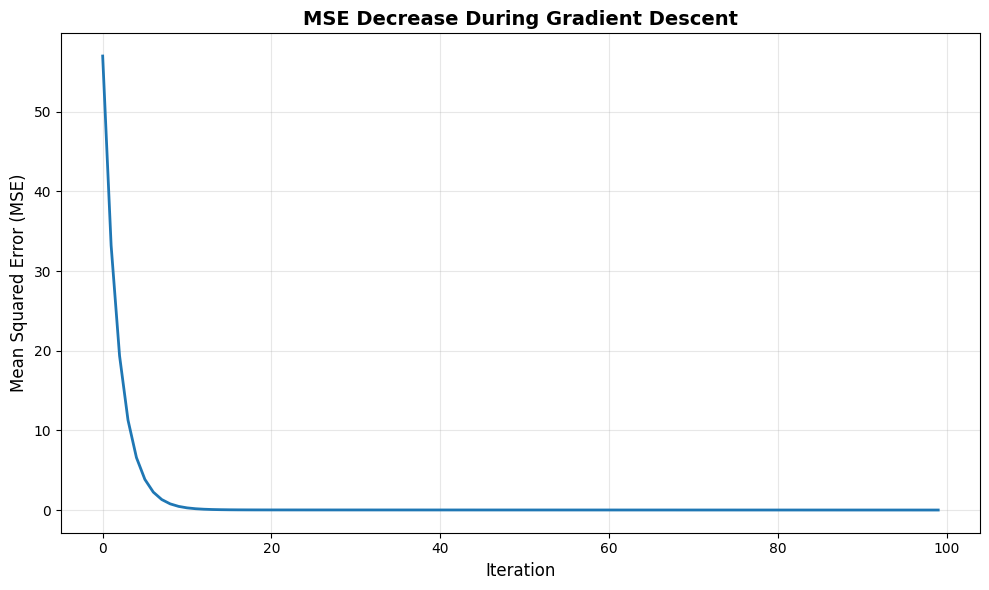

Initial MSE: 57.000000
Final MSE: 0.015974
MSE Reduction: 56.984026

Final parameters: m=2.0818, b=0.7048


In [270]:
#with plotting
def gradient_descent2(alpha, X, y, m, b, max_iter):
    X = np.atleast_2d(X).astype(float)  
    y = np.atleast_1d(y).astype(float)  
    
    mse_history = []  # Store MSE at each iteration
    
    for i in range(0, max_iter, 1):
        m_gradient = np.zeros_like(m, dtype=float)
        b_gradient = 0.0
        mse = 0.0  # Initialize MSE for this iteration
        
        for s in range(0, len(X), 1):
            prediction = np.dot(X[s], m) + b
            error = y[s] - prediction
            mse += error ** 2  # Accumulate squared errors
            m_gradient = m_gradient - (2 * X[s] * error)
            b_gradient = b_gradient - (2 * error)
        
        # Calculate mean squared error
        mse = mse / len(X)
        mse_history.append(mse)
        
        # Update parameters
        m = m - alpha * m_gradient / len(X)
        b = b - alpha * b_gradient / len(X)
    
    # Plot MSE over iterations
    plt.figure(figsize=(10, 6))
    plt.plot(range(max_iter), mse_history, linewidth=2)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
    plt.title('MSE Decrease During Gradient Descent', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Initial MSE: {mse_history[0]:.6f}")
    print(f"Final MSE: {mse_history[-1]:.6f}")
    print(f"MSE Reduction: {mse_history[0] - mse_history[-1]:.6f}")
    
    return m, b


m_fin, b_final = gradient_descent2(alpha=0.01, X=X_train, y=y_train, m=m, b=b, max_iter=100)
print(f"\nFinal parameters: m={m_final[0]:.4f}, b={b_final:.4f}")